# **Image Enhancement**

Import libraries

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

Then upload your images and load them

In [149]:
from google.colab import files
uploaded = files.upload()
imagename = list(uploaded.keys())[0]

Saving slightblur.png to slightblur (3).png


(768, 1360, 3)
float64


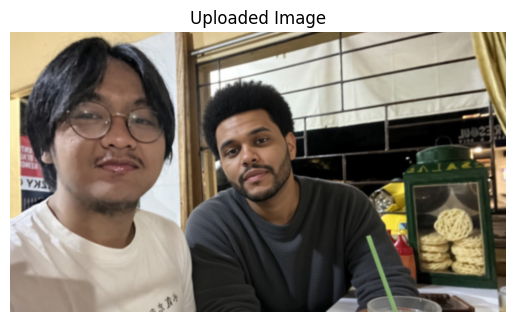

In [151]:
def load_image(imagename):
    img = Image.open(imagename).convert("RGB")
    img = np.array(img, dtype=np.float64)
    print(img.shape)
    print(img.dtype)
    return img

img = load_image(imagename)
plt.imshow(img.astype(np.uint8))
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

def show(images, titles):
    n = len(images)
    plt.figure(figsize=(5 * n, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(np.clip(images[i], 0, 255).astype(np.uint8))
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_histogram(image, title="Histogram"):
    plt.figure(figsize=(6, 3))
    if image.ndim == 3:
        colors = ('r', 'g', 'b')
        for c, color in enumerate(colors):
            plt.hist(image[:, :, c].ravel(), bins=256, range=(0, 255),
                      color=color, alpha=0.5, label=color.upper())
        plt.legend()
    else:
        plt.hist(image.ravel(), bins=256, range=(0, 255), color='gray')
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.show()

def apply_to_rgb(func, image, *args, **kwargs):
    channels = [func(*args, image=image[:, :, c], **kwargs) for c in range(3)]
    return np.stack(channels, axis=-1)

Run the image enhancements

In [152]:
def gamma_correction(gamma, image=None):
    image = img if image is None else image
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    return corrected * 255.0

def histogram_equalization(image=None):
    image = img if image is None else image
    img_int = image.astype(np.uint8)
    hist, _ = np.histogram(img_int.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_normalized = (cdf - cdf.min()) * 255.0 / (cdf.max() - cdf.min())
    cdf_mapped = cdf_normalized.astype(np.uint8)
    return cdf_mapped[img_int].astype(np.float64)

def convolve2d(kernel, image=None):
    image = img if image is None else image
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    kernel_flipped = np.flipud(np.fliplr(kernel))
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    out = np.zeros_like(image, dtype=np.float64)
    H, W = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel_flipped)
    return out

def laplacian_sharpen(image=None):
    image = img if image is None else image
    laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
    laplacian = convolve2d(laplacian_kernel, image)
    return image - laplacian

def _gaussian_kernel(ksize, sigma):
    ax = np.arange(-(ksize // 2), ksize // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def _gaussian_blur(image, ksize=5, sigma=1.5):
    kernel = _gaussian_kernel(ksize, sigma)
    return convolve2d(kernel, image)

def unsharp_mask(ksize=5, sigma=1.5, alpha=1.5, image=None):
    image = img if image is None else image
    blurred = _gaussian_blur(image, ksize, sigma)
    detail = image - blurred
    return image + alpha * detail

def gaussian_deblur(ksize=15, sigma=3.0, K=0.01, image=None):
    image = img if image is None else image
    H_img, W_img = image.shape
    kernel = _gaussian_kernel(ksize, sigma)
    psf_padded = np.zeros((H_img, W_img))
    kh, kw = kernel.shape
    psf_padded[:kh, :kw] = kernel
    psf_padded = np.roll(psf_padded, (-kh // 2, -kw // 2), axis=(0, 1))
    G = np.fft.fft2(image)
    H = np.fft.fft2(psf_padded)
    H_conj = np.conj(H)
    F_hat = (H_conj / (np.abs(H)**2 + K)) * G
    restored = np.fft.ifft2(F_hat)
    return np.abs(restored)

def median_filter(ksize=3, image=None):
    image = img if image is None else image
    pad = ksize // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')
    out = np.zeros_like(image)
    H, W = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + ksize, j:j + ksize]
            out[i, j] = np.median(region)
    return out

## Driver Code
Pick whichever enhancement you want to show on your image

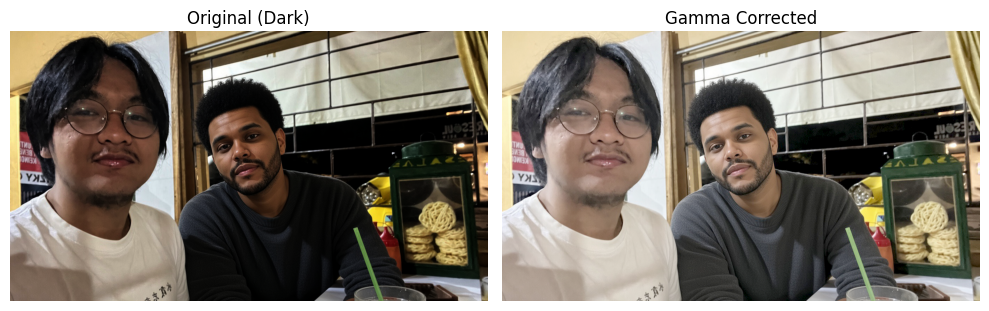

In [142]:
# Dark image -> brighten
# Works best on toodark.png
enhanced = apply_to_rgb(gamma_correction, img, gamma=0.5)
show([img, enhanced], ["Original (Dark)", "Gamma Corrected"])

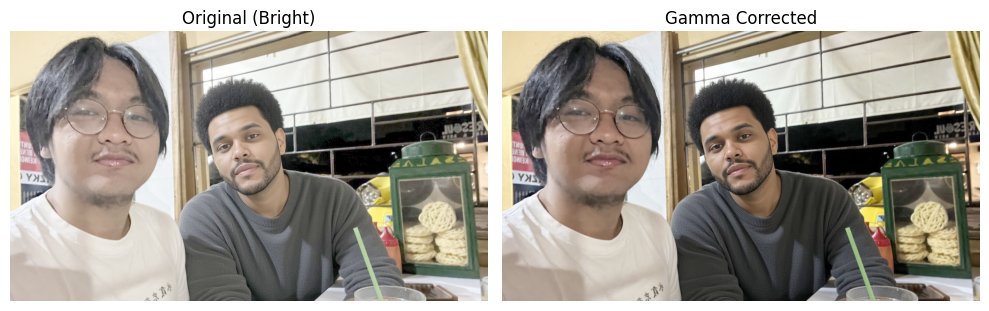

In [148]:
# Bright image -> darken
# Works best on toobright.png
enhanced = apply_to_rgb(gamma_correction, img, gamma=1.5)
show([img, enhanced], ["Original (Bright)", "Gamma Corrected"])

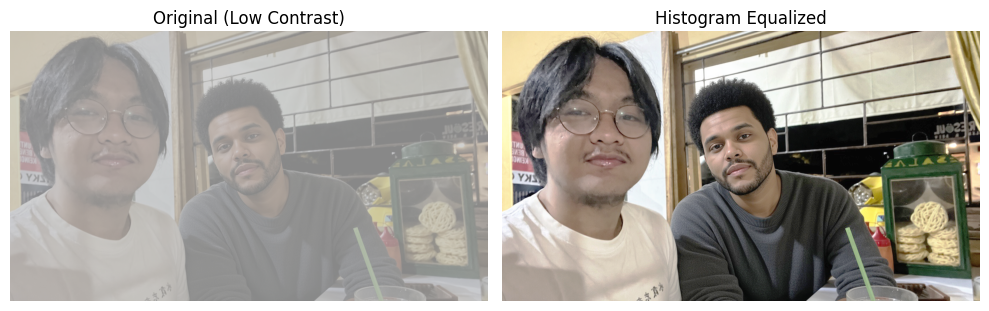

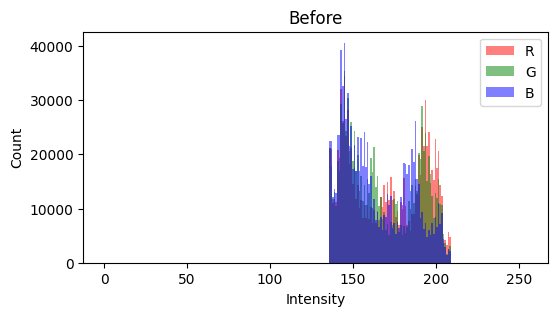

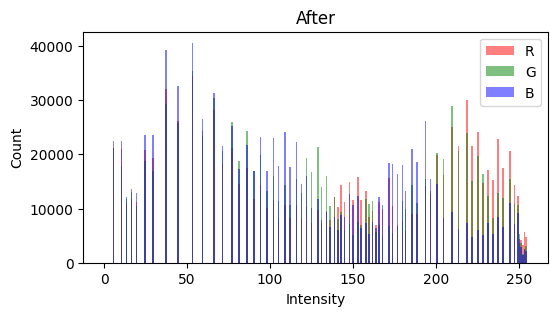

In [83]:
# Low contrast -> equalize
# Works best on lowcontrast.png
enhanced = apply_to_rgb(histogram_equalization, img)

show([img, enhanced], ["Original (Low Contrast)", "Histogram Equalized"])
show_histogram(img, "Before")
show_histogram(enhanced, "After")

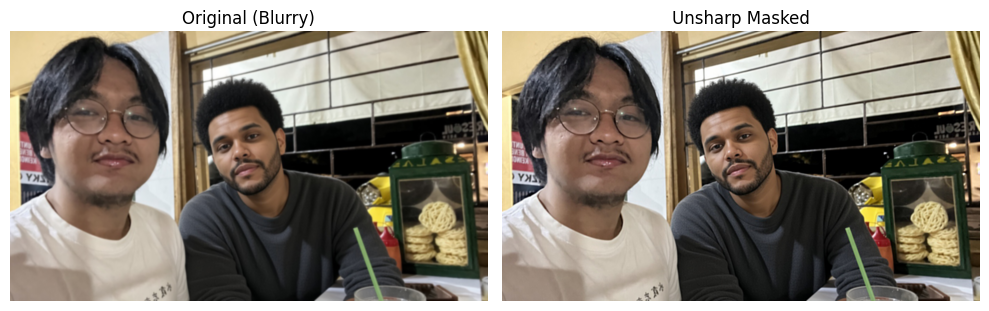

In [157]:
# Slightly blurry -> sharpen edges
# Works best on lightblur.png
enhanced = apply_to_rgb(unsharp_mask, img, ksize=9, sigma=1.5, alpha=1.5)
show([img, enhanced], ["Original (Blurry)", "Unsharp Masked"])

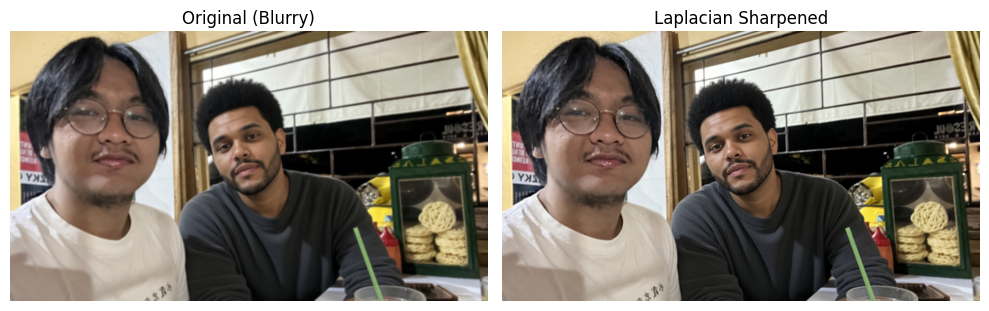

In [154]:
# Or Laplacian sharpening instead
# Works best on lightblur.png
enhanced = apply_to_rgb(laplacian_sharpen, img)
show([img, enhanced], ["Original (Blurry)", "Laplacian Sharpened"])

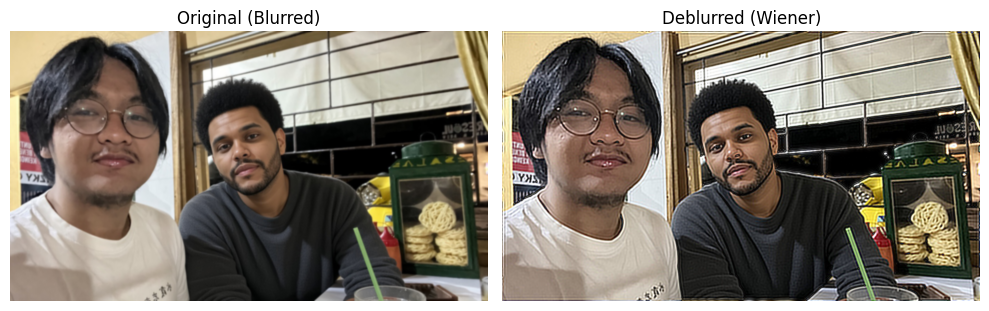

In [155]:
# Actually blurred (out-of-focus/motion) -> deconvolve
# Works best on veryblur.png or slightblur.png
enhanced = apply_to_rgb(gaussian_deblur, img, ksize=15, sigma=3.0, K=0.01)
show([img, enhanced], ["Original (Blurred)", "Deblurred (Wiener)"])

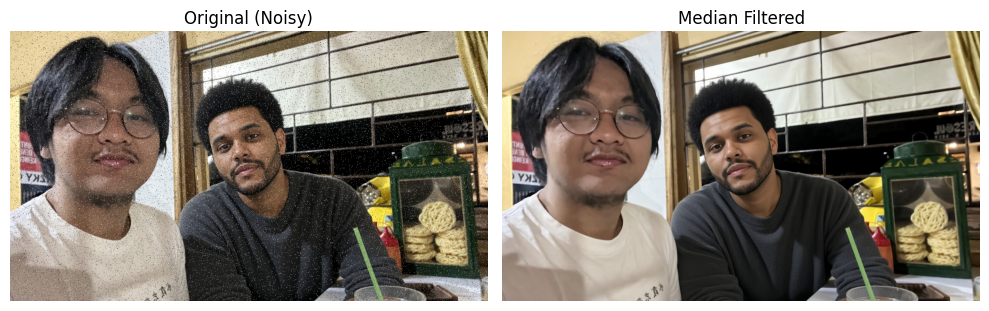

In [134]:
# Salt-and-pepper noise -> median filter
# Works best on salt_and_pepper.png
enhanced = apply_to_rgb(median_filter, img, ksize=3)
show([img, enhanced], ["Original (Noisy)", "Median Filtered"])

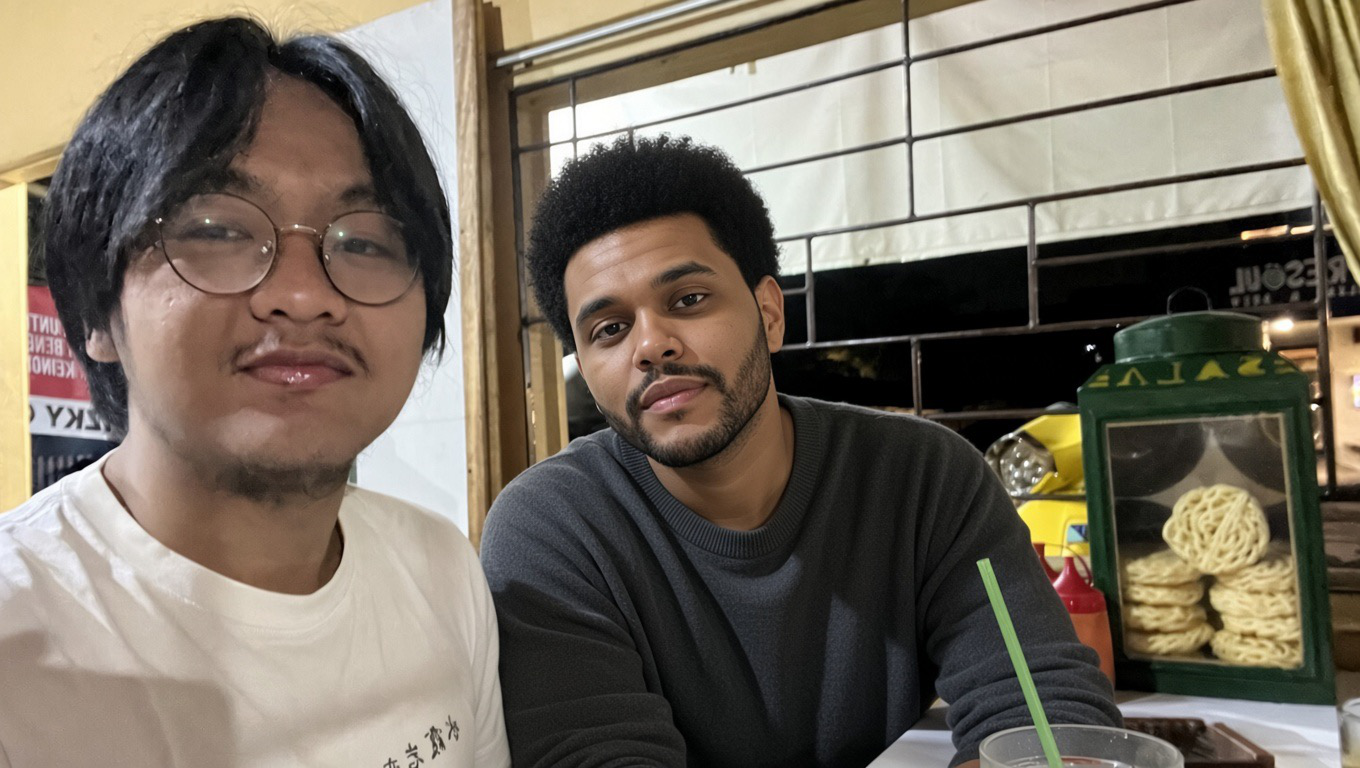